In [36]:
"""
Compute a monthly climatology for the BATS bottle dataset on a fixed depth grid.

This script downloads or reads a CSV file containing the BATS bottle data
(`3782_v9_bats_bottle.csv`), processes the time series into a tidy format,
and averages observations by calendar month and depth.  The resulting
climatology is returned as an ``xarray.Dataset`` with dimensions
``month`` and ``depth``.  Each variable in the bottle data (e.g.,
temperature, salinity, nutrients, particulate organic matter, bacterial
enumerations) is included if it exists in the input file.  Missing
depth/variable combinations are filled with ``NaN``, ensuring that all
variables share the same grid.

The workflow follows these steps:

1. **Download or open the dataset.**  A helper function
   ``load_bottle_data`` accepts either a remote URL (HTTP/HTTPS) or a local
   file path.  The CSV is read using ``pandas.read_csv`` into a
   ``DataFrame``.  Large files are streamed in chunks to conserve
   memory.
2. **Preprocess the DataFrame.**  The ``preprocess_bottle`` function
   parses the ISO8601 timestamp, extracts the month, converts depths to
   numeric and snaps them to a standard grid (0–5000 m at 10 m
   intervals by default).  It converts each selected variable to
   numeric, renames it to a simpler name and drops rows where all
   variables are missing.  If a quality flag exists for a variable,
   only values with flags 1 or 2 (unverified or verified acceptable)
   are kept; other flags (3–9) are treated as missing.
3. **Compute the climatology.**  The ``compute_monthly_climatology``
   function groups the tidy DataFrame by month and depth, computes the
   mean of each variable and returns a new DataFrame indexed by month
   and depth.
4. **Build an xarray Dataset.**  The ``build_bottle_climatology``
   function orchestrates the entire process and assembles an
   ``xarray.Dataset`` from the climatology DataFrame.  Attributes
   describing units are attached where known.

Example
-------

This example loads a local copy of the bottle dataset and writes the
climatology to a NetCDF file.  Replace the path with the remote URL to
download directly from BCO‑DMO.

.. code-block:: python

    from bats_bottle_climatology import build_bottle_climatology

    ds = build_bottle_climatology(
        '3782_v9_bats_bottle.csv',
        depth_grid=None,   # Use default 0–5000 m in 10 m steps
        depth_tolerance=5.0
    )
    print(ds)
    ds.to_netcdf('bats_bottle_monthly_climatology.nc')

The resulting dataset has coordinate variables ``month`` and ``depth``, and
one data variable per bottle measurement.

Notes
-----

* The default depth grid covers the full range of sampling depths (0–5000 m)
  at 10 m resolution.  If you wish to limit the depth range (e.g.,
  surface waters) or use a coarser resolution, supply a different
  ``numpy.ndarray`` via the ``depth_grid`` argument.
* Variables are selected based on the ``VARIABLES`` mapping defined
  below.  Only columns present in the CSV are included in the
  climatology.  To add or remove variables, edit the ``VARIABLES`` and
  ``FLAG_COLUMNS`` dictionaries.
* Quality flags follow the SeaDataNet convention: 1 = unverified, 2 =
  acceptable, 3 = questionable, 4 = bad, 9 = no data.  Only values
  flagged 1 or 2 contribute to the climatology.  Missing flags are
  ignored.
"""

from __future__ import annotations

import io
import warnings
from typing import Dict, Iterable, Optional

import numpy as np
import pandas as pd
import requests
import xarray as xr

import os
wrkdir = "/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations"
os.chdir(wrkdir)
os.getcwd()


'/g/data/vn19/pjb581/WOMBATmid-Optimization/data/observations'

In [11]:

# Default depth grid: 0 to 5000 m in 10 m increments.
DEFAULT_DEPTH_GRID: np.ndarray = np.arange(0.0, 300.0 + 1.0, 20.0)

# Default allowable deviation when snapping depths to the standard grid
DEFAULT_DEPTH_TOLERANCE: float = 10.0

# Names of variables to extract from the bottle dataset.
# Keys correspond to column names in the raw CSV; values are names used
# in the output dataset.  Variables absent from the dataset are ignored.
VARIABLES: Dict[str, str] = {
    'Temperature': 'temperature',
    'CTD_Salinity': 'ctd_salinity',
    'Salinity': 'salinity',
    'Sigma_theta': 'sigma_theta',
    'Oxygen_1': 'oxygen',
    'CO2': 'dic',
    'Alkalinity': 'alkalinity',
    'NO3_plus_NO2': 'nitrate_plus_nitrite',
    'NO2': 'nitrite',
    'PO4': 'phosphate',
    'Silicate': 'silicate',
    'POC': 'poc',
    'PON': 'pon',
    'TOC': 'toc',
    'TN': 'tn',
    'Bact_Enum': 'bacteria_abundance',
    'POP': 'pop',
    'TDP': 'tdp',
    'SRP': 'srp',
    'Bio_Si': 'bio_si',
    'Litho_Si': 'litho_si',
    'Prochlorococcus': 'prochlorococcus',
    'Synechococcus': 'synechococcus',
    'Picoeukaryotes': 'picoeukaryotes',
    'Nanoeukaryotes': 'nanoeukaryotes',
}

# Mapping from variables to their quality flag columns.  If a flag
# column exists, only values with flag 1 or 2 are retained.  This
# dictionary uses the output names defined in ``VARIABLES``.
FLAG_COLUMNS: Dict[str, str] = {
    'temperature': 'QF_Temp',
    'ctd_salinity': 'QF_CTD_Sal',
    'salinity': 'QF_Salinity',
    'sigma_theta': 'QF_Sigma_theta',
    'oxygen': 'QF_Oxygen',
    'dic': 'QF_DIC',
    'alkalinity': 'QF_Alk',
    'nitrate_plus_nitrite': 'QF_NO3_NO2',
    'nitrite': 'QF_NO2',
    'phosphate': 'QF_PO4',
    'silicate': 'QF_Silicate',
    'poc': 'QF_POC',
    'pon': 'QF_PON',
    'toc': 'QF_TOC',
    'tn': 'QF_TN',
    'bacteria_abundance': 'QF_Bact_enum',
    'pop': 'QF_POP',
    'tdp': 'QF_TDP',
    'srp': 'QF_LLP_SRP',
    'bio_si': 'QF_bio_Si',
    'litho_si': 'QF_litho_Si',
    'prochlorococcus': 'QF_Prochloro',
    'synechococcus': 'QF_Synecho',
    'picoeukaryotes': 'QF_Picoeuk',
    'nanoeukaryotes': 'QF_Nanoeuk',
}

# Units metadata for variables.  Where units are unknown or not
# applicable, the value can be ``None``.  You can edit this mapping
# based on the dataset documentation.  Only included variables will
# appear in the final dataset.
UNITS: Dict[str, Optional[str]] = {
    'temperature': 'degree_Celsius',
    'ctd_salinity': 'PSU',
    'salinity': 'PSU',
    'sigma_theta': 'kg/m3',
    'oxygen': 'micromole_per_kg',
    'dic': 'micromole_per_kg',
    'alkalinity': 'microequivalent_per_kg',
    'nitrate_plus_nitrite': 'micromole_per_kg',
    'nitrite': 'micromole_per_kg',
    'phosphate': 'micromole_per_kg',
    'silicate': 'micromole_per_kg',
    'poc': 'micromole_per_kg',
    'pon': 'micromole_per_kg',
    'toc': 'micromole_per_kg',
    'tn': 'micromole_per_kg',
    'bacteria_abundance': 'cells_per_ml',
    'pop': 'micromole_per_kg',
    'tdp': 'micromole_per_kg',
    'srp': 'micromole_per_kg',
    'bio_si': 'micromole_per_kg',
    'litho_si': 'micromole_per_kg',
    'prochlorococcus': 'cells_per_ml',
    'synechococcus': 'cells_per_ml',
    'picoeukaryotes': 'cells_per_ml',
    'nanoeukaryotes': 'cells_per_ml',
}

### DOWNLOAD

In [18]:
def load_bottle_data(path_or_url: str) -> pd.DataFrame:
    """Load the BATS bottle CSV into a pandas DataFrame.

    If the input is an HTTP(S) URL, the file is downloaded using
    ``requests``.  Local paths are passed directly to ``pandas.read_csv``.
    The CSV is read in chunks to limit memory usage.

    Parameters
    ----------
    path_or_url : str
        Path or URL of the CSV file.

    Returns
    -------
    pandas.DataFrame
        The concatenated DataFrame containing all records.
    """
    if path_or_url.startswith(('http://', 'https://')):
        # For remote URLs, let pandas handle the download.  Pandas can
        # directly read HTTP(S) URLs via urllib.  This avoids issues with
        # passing a generator to ``read_csv``, which expects a path or
        # file-like object.
        try:
            df = pd.read_csv(path_or_url)
        except Exception:
            # Fallback: explicitly download the content and read from
            # an in-memory buffer.  This may use more memory but is
            # robust to different server configurations.
            resp = requests.get(path_or_url)
            resp.raise_for_status()
            df = pd.read_csv(io.BytesIO(resp.content))
    else:
        df = pd.read_csv(path_or_url)
    return df



### PROCESS

In [13]:
def preprocess_bottle(
    df: pd.DataFrame,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
) -> pd.DataFrame:
    """Preprocess the BATS bottle DataFrame for climatology.

    This function performs the following steps:

    * Parses the ISO8601 date string and extracts the calendar month (1–12).
    * Converts the depth column to numeric and snaps values to a fixed
      grid within a specified tolerance.  Samples outside the tolerance
      are discarded.
    * Applies quality flags to filter out questionable or bad data.
    * Converts selected variables to numeric and renames them.
    * Drops rows where all selected variables are missing.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw BATS bottle dataset.
    depth_grid : numpy.ndarray, optional
        Sorted array of depth levels to which sample depths should be
        snapped.  If omitted, ``DEFAULT_DEPTH_GRID`` is used.
    depth_tolerance : float, optional
        Maximum absolute difference (in metres) between an original
        sample depth and the nearest grid level for the sample to be
        considered valid.

    Returns
    -------
    pandas.DataFrame
        Tidy DataFrame with columns ``month`` (int), ``depth`` (float)
        and one column per selected variable.  If no valid data remain
        after preprocessing, an empty DataFrame is returned.
    """
    if df.empty:
        return df
    if depth_grid is None:
        depth_grid = DEFAULT_DEPTH_GRID
    # Parse the ISO datetime column
    date_col = 'ISO_DateTime_UTC' if 'ISO_DateTime_UTC' in df.columns else None
    if date_col is None:
        raise ValueError("'ISO_DateTime_UTC' column is required for time parsing.")
    df = df.copy()
    df['datetime'] = pd.to_datetime(df[date_col], errors='coerce')
    df.dropna(subset=['datetime'], inplace=True)
    df['month'] = df['datetime'].dt.month.astype(int)
    # Convert depth and snap to grid
    if 'Depth' not in df.columns:
        raise ValueError("'Depth' column is required for depth processing.")
    df['depth_orig'] = pd.to_numeric(df['Depth'], errors='coerce')
    df.dropna(subset=['depth_orig'], inplace=True)
    # Find nearest grid index for each sample
    idxs = np.abs(df['depth_orig'].values[:, None] - depth_grid[None, :]).argmin(axis=1)
    snapped = depth_grid[idxs]
    within = np.abs(df['depth_orig'] - snapped) <= depth_tolerance
    # Keep only samples within tolerance
    df = df.loc[within].copy()
    df['depth'] = snapped[within.values]
    # Initialize a list for processed variable names present in the file
    present_vars: list[str] = []
    # Convert variables to numeric, apply quality flags, rename
    for raw_name, out_name in VARIABLES.items():
        if raw_name not in df.columns:
            continue
        # Apply quality flag if available
        flag_col = FLAG_COLUMNS.get(out_name)
        series = pd.to_numeric(df[raw_name], errors='coerce')
        if flag_col in df.columns:
            # Keep values with flag 1 or 2 only
            good = df[flag_col].isin([1, 2])
            series = series.where(good)
        # Keep column only if there is at least one non-NA value
        if series.notna().any():
            df[out_name] = series
            present_vars.append(out_name)
    if not present_vars:
        warnings.warn("None of the selected variables were found in the bottle data.")
        return pd.DataFrame()
    # Drop rows where all selected variables are NA
    df.dropna(subset=present_vars, how='all', inplace=True)
    return df[['month', 'depth'] + present_vars]


### CLIMATOLOGY

In [14]:
def compute_monthly_climatology(df: pd.DataFrame) -> pd.DataFrame:
    """Aggregate the tidy bottle data by month and depth.

    Group by ``month`` and ``depth`` and compute the mean of all
    variables.  Missing values are ignored in the mean.  The output
    index is a MultiIndex (month, depth).

    Parameters
    ----------
    df : pandas.DataFrame
        Preprocessed DataFrame with columns ``month``, ``depth`` and
        variables to average.

    Returns
    -------
    pandas.DataFrame
        DataFrame indexed by ``month`` and ``depth`` with one column
        per variable.
    """
    if df.empty:
        return df
    grouped = df.groupby(['month', 'depth'], as_index=True)
    clim = grouped.mean(numeric_only=True)
    # Ensure month and depth are sorted
    clim.sort_index(inplace=True)
    return clim
    

### BUILD

In [15]:
def build_bottle_climatology(
    path_or_url: str,
    depth_grid: Optional[np.ndarray] = None,
    depth_tolerance: float = DEFAULT_DEPTH_TOLERANCE,
) -> xr.Dataset:
    """Load the BATS bottle dataset and compute a monthly climatology.

    Parameters
    ----------
    path_or_url : str
        Local file path or remote URL pointing to the bottle dataset CSV.
    depth_grid : numpy.ndarray, optional
        Depth grid onto which observations are interpolated/snapped.
        Defaults to ``DEFAULT_DEPTH_GRID`` if omitted.
    depth_tolerance : float, optional
        Maximum deviation between original and snapped depth for a
        sample to be included.  Defaults to ``DEFAULT_DEPTH_TOLERANCE``.

    Returns
    -------
    xarray.Dataset
        Dataset containing monthly climatologies for each variable on
        the specified depth grid.  If no data are available, an empty
        Dataset is returned.
    """
    raw_df = load_bottle_data(path_or_url)
    tidy = preprocess_bottle(raw_df, depth_grid=depth_grid, depth_tolerance=depth_tolerance)
    if tidy.empty:
        return xr.Dataset()
    clim_df = compute_monthly_climatology(tidy)
    # Extract coordinate arrays
    months = np.sort(tidy['month'].unique())
    depths = depth_grid if depth_grid is not None else DEFAULT_DEPTH_GRID
    # Build empty dataset with coordinates
    ds = xr.Dataset()
    # Determine variable names from columns
    var_names = clim_df.columns.tolist()
    # Unstack MultiIndex to 2D array for each variable
    clim_unstacked = clim_df.unstack(level=0)  # index (depth), columns (month, var)
    # The unstack returns DataFrame with multi-level columns: top level = variable, second level = month
    for var in var_names:
        if var not in clim_unstacked.columns.get_level_values(0):
            continue
        # DataFrame for this variable with columns by month
        var_df = clim_unstacked[var]
        # Align depths to full depth grid; reindex to ensure missing depths are included
        var_df = var_df.reindex(depths, fill_value=np.nan)
        # Align months to all 12 months (1-12)
        all_months = np.arange(1, 13)
        var_df = var_df.reindex(columns=all_months, fill_value=np.nan)
        data = var_df.values.astype(float)
        # Create DataArray
        da = xr.DataArray(
            data,
            coords={'depth': depths, 'month': all_months},
            dims=['depth', 'month'],
            name=var,
            attrs={'units': UNITS.get(var)}
        )
        ds[var] = da
    # Assign coordinate attributes
    ds['depth'].attrs['units'] = 'meters'
    ds['month'].attrs['long_name'] = 'Calendar month'
    return ds

### call

In [20]:
%%time

link = "https://datadocs.bco-dmo.org/dataset/3782/file/wn3zAMZuP0Arwj/3782_v9_bats_bottle.csv"
ds = build_bottle_climatology(link)
print(ds)


<xarray.Dataset> Size: 39kB
Dimensions:               (depth: 16, month: 12)
Coordinates:
  * depth                 (depth) float64 128B 0.0 20.0 40.0 ... 280.0 300.0
  * month                 (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables: (12/25)
    temperature           (depth, month) float64 2kB 20.93 20.17 ... 18.47 18.5
    ctd_salinity          (depth, month) float64 2kB 36.68 36.68 ... 36.59 36.59
    salinity              (depth, month) float64 2kB 36.69 36.68 ... 36.57 36.56
    sigma_theta           (depth, month) float64 2kB 25.79 26.0 ... 26.38 26.37
    oxygen                (depth, month) float64 2kB 218.7 222.2 ... 202.4 201.3
    dic                   (depth, month) float64 2kB 2.07e+03 ... 2.109e+03
    ...                    ...
    bio_si                (depth, month) float64 2kB 19.84 17.64 ... 13.28 9.14
    litho_si              (depth, month) float64 2kB 3.465 4.444 ... 5.364 5.926
    prochlorococcus       (depth, month) float64 2kB 3.971e+04 3.71

In [26]:
ds.data_vars

Data variables:
    temperature           (depth, month) float64 2kB 20.93 20.17 ... 18.47 18.5
    ctd_salinity          (depth, month) float64 2kB 36.68 36.68 ... 36.59 36.59
    salinity              (depth, month) float64 2kB 36.69 36.68 ... 36.57 36.56
    sigma_theta           (depth, month) float64 2kB 25.79 26.0 ... 26.38 26.37
    oxygen                (depth, month) float64 2kB 218.7 222.2 ... 202.4 201.3
    dic                   (depth, month) float64 2kB 2.07e+03 ... 2.109e+03
    alkalinity            (depth, month) float64 2kB 2.399e+03 ... 2.392e+03
    nitrate_plus_nitrite  (depth, month) float64 2kB 0.1109 0.09833 ... 3.698
    nitrite               (depth, month) float64 2kB 0.03102 ... 0.001246
    phosphate             (depth, month) float64 2kB 0.002639 ... 0.1607
    silicate              (depth, month) float64 2kB 0.8263 0.7926 ... 1.491
    poc                   (depth, month) float64 2kB 24.8 30.58 ... 8.525 7.481
    pon                   (depth, month) float

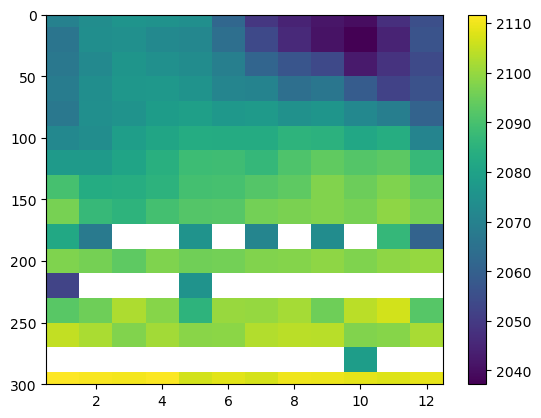

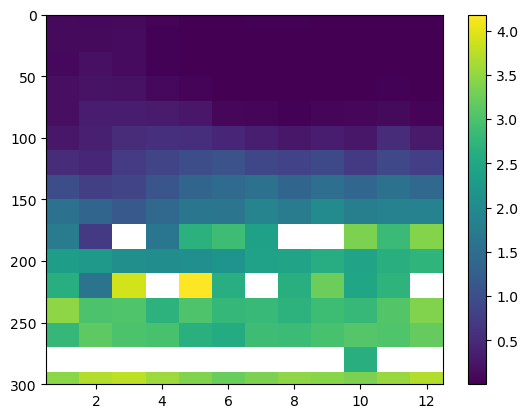

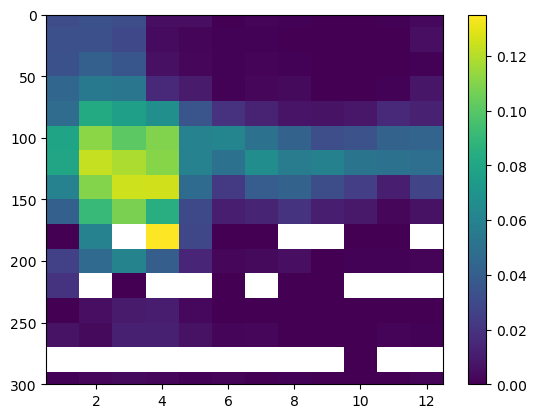

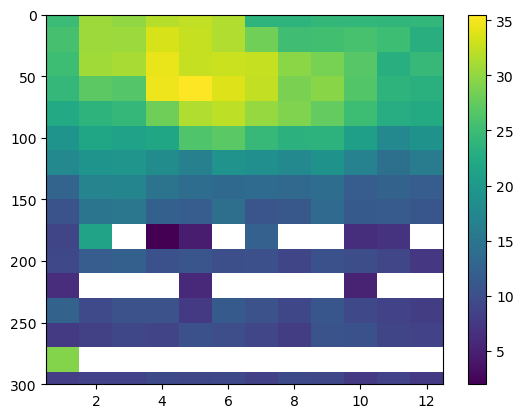

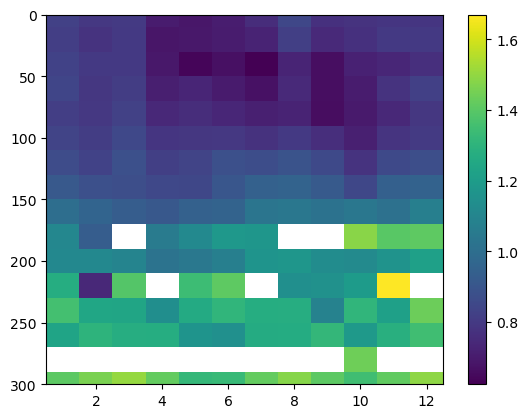

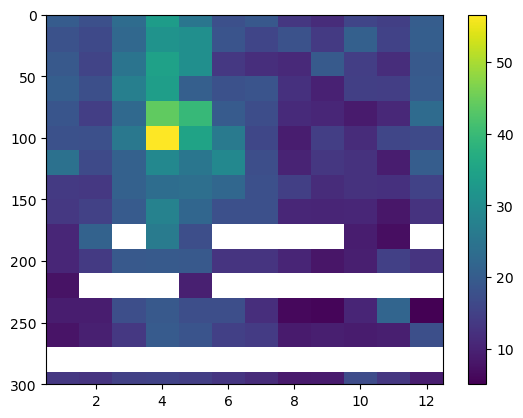

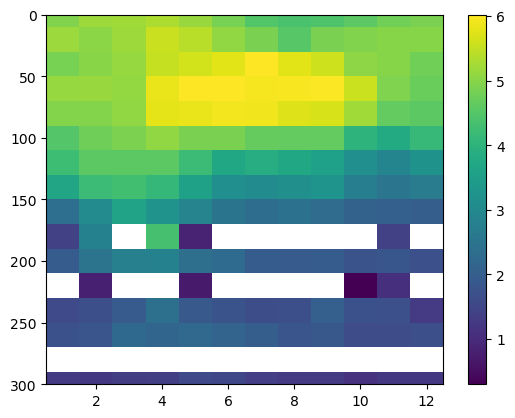

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['dic'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['nitrate_plus_nitrite'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['nitrite'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['poc'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['silicate'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['bio_si'])
plt.ylim(300,0)
plt.colorbar()

plt.figure()
plt.pcolormesh(ds.coords['month'], ds.coords['depth'], ds['bacteria_abundance'])
plt.ylim(300,0)
plt.colorbar()


### SAVE

In [24]:
%%time
    
ds.to_netcdf('./bats_bottledata_monthly_climatology.nc')

CPU times: user 256 ms, sys: 151 ms, total: 407 ms
Wall time: 1.53 s
